In [ ]:
import math
import pandas as pd

rho_l = 1504   # POM Orange
rho_h = 1933   # Epoxy
C = 0.15       # volumefraktion i bed (antagelse)

# [c, b, a, m] 
data_heavy_1_8 = [
    [1.89, 3.73, 10.33, 0.0488],
    [2.51, 4.52, 5.60, 0.0489],
    [3.02, 4.20, 7.55, 0.0515],
    [3.63, 3.68, 6.50, 0.0578],
    [3.20, 4.48, 10.02, 0.0834],
    [2.27, 4.22, 7.35, 0.0448],
    [3.43, 4.17, 5.71, 0.0511],
    [3.08, 4.31, 6.54, 0.0630],
    [2.60, 4.66, 7.47, 0.0594],
    [2.99, 4.27, 8.74, 0.0633],
    [2.45, 3.96, 11.55, 0.0553],
    [2.22, 4.16, 5.92, 0.0481],
    [2.64, 5.46, 6.31, 0.0518],
    [2.47, 3.16, 5.93, 0.0407],
    [2.42, 5.23, 6.89, 0.0484],
    [1.48, 5.24, 8.64, 0.0383],
    [1.62, 4.25, 9.65, 0.0515],
    [1.69, 5.24, 6.63, 0.0382],
    [2.67, 4.80, 7.92, 0.0664],
    [4.03, 4.23, 7.25, 0.0881],
    [2.75, 2.94, 6.98, 0.0445],
    [1.82, 4.37, 6.35, 0.0391],
    [3.16, 3.46, 6.32, 0.0595],
    [2.36, 4.57, 8.39, 0.0677],
    [1.89, 4.01, 6.80, 0.0412]
]

data_heavy_4 = [
    [4.88, 5.53, 9.99, 0.2654],
    [4.64, 7.28, 11.01, 0.2251],
    [3.43, 7.39, 11.25, 0.1844],
    [3.46, 4.82, 8.00, 0.1056],
    [2.49, 5.28, 8.81, 0.0746],
    [4.16, 4.36, 7.70, 0.0774],
    [3.40, 5.90, 7.63, 0.1134],
    [4.42, 4.76, 8.19, 0.1330],
    [4.51, 5.54, 7.97, 0.1104],
    [4.45, 6.91, 9.61, 0.1942],
    [5.54, 6.14, 14.35, 0.3560],
    [4.90, 5.92, 8.57, 0.2283],
    [2.49, 5.05, 6.14, 0.0533],
    [4.08, 6.39, 9.76, 0.1501],
    [5.08, 6.04, 9.32, 0.2326],
    [5.82, 6.42, 11.54, 0.3616],
    [3.84, 8.37, 13.59, 0.3051],
    [4.76, 6.16, 9.08, 0.1598],
    [4.64, 5.04, 11.09, 0.1965],
    [4.72, 6.11, 7.73, 0.1584],
    [4.72, 6.43, 9.69, 0.1778],
    [4.21, 6.44, 13.45, 0.2295],
    [5.06, 6.35, 8.22, 0.1662],
    [3.79, 4.73, 11.22, 0.1181],
    [4.17, 5.31, 7.74, 0.1221]
]

data_heavy_6_3 = [
    [5.13, 6.83, 9.46, 0.2793],
    [5.17, 8.98, 12.49, 0.3811],
    [5.45, 8.83, 13.18, 0.6560],
    [5.59, 7.44, 12.21, 0.3900],
    [6.35, 6.56, 12.57, 0.4503],
    [3.48, 9.30, 12.98, 0.2441],
    [5.73, 9.98, 13.47, 0.4968],
    [6.42, 6.62, 11.92, 0.5399],
    [2.61, 8.76, 10.60, 0.2103],
    [4.65, 8.02, 11.58, 0.4227],
    [6.82, 7.52, 13.68, 0.6593],
    [4.89, 8.07, 15.39, 0.4290],
    [5.40, 6.69, 10.31, 0.2440],
    [5.67, 6.75, 12.37, 0.4486],
    [3.91, 8.16, 13.72, 0.4238],
    [6.25, 10.29, 14.19, 0.5766],
    [6.35, 9.17, 11.95, 0.4906],
    [4.54, 7.11, 10.04, 0.2726],
    [5.74, 7.02, 11.72, 0.4003],
    [4.17, 10.90, 14.48, 0.4518],
    [5.87, 6.51, 12.21, 0.4074],
    [7.31, 8.09, 11.84, 0.6765],
    [7.39, 8.34, 11.39, 0.5233],
    [6.59, 8.04, 10.90, 0.4935],
    [5.90, 7.24, 12.12, 0.4168]
]

data_light_1_8 = [
    [2.17, 6.11, 8.66, 0.0585],
    [2.73, 3.29, 7.20, 0.0636],
    [3.78, 5.08, 7.76, 0.0692],
    [3.15, 5.50, 8.97, 0.0890],
    [3.63, 4.31, 7.95, 0.0919],
    [3.02, 4.01, 6.21, 0.0560],
    [3.61, 3.91, 6.77, 0.0669],
    [3.20, 4.26, 5.98, 0.0455],
    [3.87, 4.49, 6.96, 0.0764],
    [2.79, 4.00, 7.81, 0.0550],
    [3.16, 3.79, 5.52, 0.0380],
    [2.92, 3.42, 5.76, 0.0438],
    [3.11, 3.90, 5.21, 0.0433],
    [4.00, 4.40, 10.62, 0.0682],
    [3.48, 4.17, 7.55, 0.0081],
    [3.20, 3.87, 5.48, 0.0429],
    [3.53, 3.99, 6.53, 0.0623],
    [3.38, 3.85, 7.94, 0.0766],
    [3.76, 4.17, 5.80, 0.0479],
    [3.89, 5.84, 7.15, 0.0625],
    [2.90, 4.20, 7.88, 0.0650],
    [3.23, 4.07, 9.58, 0.0755],
    [2.43, 3.30, 4.80, 0.0232],
    [2.66, 4.19, 6.31, 0.0467],
    [3.29, 3.90, 7.33, 0.0640]
]

data_light_4 = [
    [3.51, 4.93, 6.24, 0.0782],
    [4.23, 5.54, 6.33, 0.0954],
    [3.35, 6.44, 9.67, 0.1549],
    [3.17, 5.58, 9.02, 0.0872],
    [3.78, 6.28, 6.88, 0.0998],
    [4.14, 5.36, 5.69, 0.1034],
    [3.64, 6.77, 7.38, 0.0929],
    [4.48, 5.09, 7.18, 0.1192],
    [4.52, 6.51, 10.56, 0.1870],
    [5.70, 5.84, 7.65, 0.1611],
    [4.30, 5.38, 6.53, 0.0947],
    [5.79, 6.71, 8.61, 0.1719],
    [5.18, 5.53, 8.62, 0.1755],
    [5.25, 5.98, 8.19, 0.1525],
    [4.02, 6.66, 10.09, 0.1576],
    [3.45, 5.06, 7.81, 0.0941],
    [3.75, 7.63, 9.37, 0.1814],
    [5.10, 7.55, 11.78, 0.2169],
    [4.43, 6.13, 7.34, 0.1252],
    [4.35, 5.28, 8.46, 0.1401],
    [3.09, 5.46, 8.22, 0.0731],
    [5.56, 5.63, 7.77, 0.1517],
    [4.48, 6.60, 7.58, 0.1384],
    [5.23, 5.78, 8.64, 0.1769],
    [4.22, 5.83, 8.76, 0.1360]
]

data_light_6_3 = [
    [5.84, 7.21, 9.04, 0.2518],
    [5.72, 10.15, 15.55, 0.4969],
    [5.27, 9.22, 11.30, 0.3411],
    [5.54, 6.52, 9.31, 0.2426],
    [5.54, 7.67, 10.80, 0.2982],
    [5.73, 9.61, 11.17, 0.4174],
    [5.04, 5.28, 11.08, 0.2255],
    [5.17, 9.54, 9.98, 0.2754],
    [5.04, 8.11, 10.28, 0.2747],
    [4.79, 9.13, 11.42, 0.1999],
    [5.92, 6.56, 12.21, 0.2557],
    [5.51, 7.22, 10.46, 0.2522],
    [5.89, 7.98, 10.18, 0.3147],
    [5.80, 6.93, 11.09, 0.2900],
    [5.41, 6.71, 10.67, 0.2875],
    [6.93, 9.25, 12.06, 0.3792],
    [6.07, 7.41, 10.74, 0.3279],
    [4.56, 7.74, 11.06, 0.2452],
    [5.46, 8.05, 9.21, 0.2625],
    [4.87, 8.50, 12.64, 0.3077],
    [5.44, 7.11, 9.37, 0.2200],
    [5.71, 7.19, 8.80, 0.2465],
    [5.50, 7.44, 10.08, 0.3035],
    [5.43, 7.25, 10.34, 0.2730],
    [5.30, 7.51, 11.13, 0.3447]
]

data_light = data_light_6_3 + data_light_4 + data_light_6_3
data_heavy = data_heavy_6_3 + data_heavy_4 + data_heavy_6_3

rho_f = 998.2        # Vand [kg/m3]
mu    = 1.0016e-3    # [Pa*s]
nu    = mu / rho_f   # [m^2/s]
g     = 9.82         # [m/s2]

def Cd_Goral(Re, psi):
    Gamma = 1 + (3.2 / math.sqrt(Re)) + (32 / Re)
    Ypsilon = min(0.44*psi**-2, 1) 
    return Gamma * Ypsilon


def terminal_velocity_Goral(a, b, c, m, psi, rho_p, dD, v0=0.05, iters=100): 
    s = rho_p / rho_f                     # Relativ densitet af partiklen
    V = m / rho_p                         # Volumen 
    dp = math.sqrt(a*b)                   # Karakteristiske længde for en irregulær partikel
    dV = (6*V / math.pi)**(1/3)           # Volumenækvivalent diameter
    dn = (a*b*c)**(1/3)                   # Nominal diameter

    if dD == "dV":
        dD = dV
    elif dD == "dn":
        dD = dn
    elif dD == "c":
        dD = c

    v = v0
    for _ in range(iters):    
        Re = dp*v / nu
        Cd = Cd_Goral(Re, psi)
        v = math.sqrt((4 * g * (s-1) * dD) / (3 * Cd)) 
    Re = dp*v / nu
    Cd = Cd_Goral(Re, psi)
    return v, Re, Cd, V

def n_richardson_zaki(Re):
    if Re < 1:
        return 4.65
    elif Re < 1000:
        return 4.45*(Re**(-0.1))
    else:
        return 2.39

def build_df_from_matrix(data_mm):
    df = pd.DataFrame(data_mm, columns=["c","b","a","m"]) / 1000 # Milimeter til meter
    df["psi"] = (df["c"]**2/(df["b"]*df["a"]))**(1/3)
    df["c_mm"] = df["c"] * 1000     # Meter til milimeter
    df["b_mm"] = df["b"] * 1000     # Meter til milimeter
    df["a_mm"] = df["a"] * 1000     # Meter til milimeter
    df["m_gram"] = df["m"] * 1000   # Meter til milimeter
    return df

def calculate(data_mm, rho_p, C, dD):
    df = build_df_from_matrix(data_mm)
    v_list, Re_list, Cd_list, vh_list, V_list, dn_list, dV_list = [], [], [], [], [], [], []
    for _, r in df.iterrows():
        v, Re, Cd, V = terminal_velocity_Goral(r["a"], r["b"], r["c"], r["m"], r["psi"], rho_p, dD) 
        n = n_richardson_zaki(Re)
        vh = v*((1-C)**n)
        dn = (r["a"] * r["b"] * r["c"])**(1/3) * 1000 # Meter til milimeter
        dV = (6*V / math.pi)**(1/3) * 1000            # Meter til milimeter
        V *= 10**6                                    # m^3 til cm^3
        v_list.append(v); Re_list.append(Re); Cd_list.append(Cd); vh_list.append(vh); V_list.append(V); dn_list.append(dn); dV_list.append(dV)

    df[f"v_single_m/s"]   = v_list
    df[f"v_hindered_m/s"] = vh_list
    df[f"Re"]             = Re_list
    df[f"Cd"]             = Cd_list
    df[f"V_cm^3"]         = V_list
    df[f"dn_mm"]          = dn_list
    df[f"dV_mm"]          = dV_list
    return df

># Terminalhastighed med dV

In [2]:
df_light = calculate(data_light, rho_p=rho_l, C=C, dD = "dV")
df_heavy = calculate(data_heavy, rho_p=rho_h, C=C, dD = "dV")

cols = ["psi","Re","Cd","v_single_m/s","v_hindered_m/s", "a_mm", "b_mm", "c_mm", "m_gram", "V_cm^3", "dn_mm", "dV_mm"]

for df, label in [(df_light, "LIGHT (POM)"), (df_heavy, "HEAVY (Epoxy)")]:
    d = df[cols].reset_index(drop=True)
    d.index += 1
    d.loc["Mean"] = d.mean()
    styled = (d.style.format("{:.4f}").set_caption(label)
               .set_properties(subset=pd.IndexSlice["Mean", :], **{"font-weight": "bold"}))
    display(styled)

,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.8058,1996.2669,0.7370,0.2481,0.1682,9.0400,7.2100,5.8400,0.2518,0.1674,7.2472,6.8381
2,0.5918,2886.5192,1.0706,0.2305,0.1563,15.5500,10.1500,5.7200,0.4969,0.3304,9.6649,8.5771
3,0.6436,2190.0836,1.0830,0.2153,0.1460,11.3000,9.2200,5.2700,0.3411,0.2268,8.1885,7.5662
4,0.7967,1890.2998,0.7560,0.2434,0.1651,9.3100,6.5200,5.5400,0.2426,0.1613,6.9540,6.7538
5,0.7182,2064.8596,0.9262,0.2276,0.1544,10.8000,7.6700,5.5400,0.2982,0.1983,7.7133,7.2347
6,0.6738,2338.6779,1.0466,0.2265,0.1536,11.1700,9.6100,5.7300,0.4174,0.2775,8.5044,8.0929
7,0.7572,1738.8687,0.8404,0.2281,0.1547,11.0800,5.2800,5.0400,0.2255,0.1499,6.6558,6.5912
8,0.6548,2016.4164,1.0871,0.2074,0.1406,9.9800,9.5400,5.1700,0.2754,0.1831,7.8957,7.0454
9,0.6729,1910.8380,1.0592,0.2100,0.1424,10.2800,8.1100,5.0400,0.2747,0.1826,7.4900,7.0394
10,0.6037,2000.0144,1.0876,0.1965,0.1333,11.4200,9.1300,4.7900,0.1999,0.1329,7.9340,6.3317


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.7413,2436.1640,0.8632,0.3041,0.2062,9.4600,6.8300,5.1300,0.2793,0.1445,6.9206,6.5105
2,0.6200,3038.1876,1.0686,0.2879,0.1952,12.4900,8.9800,5.1700,0.3811,0.1972,8.3389,7.2211
3,0.6343,3394.7463,1.0643,0.3158,0.2141,13.1800,8.8300,5.4500,0.6560,0.3394,8.5919,8.6542
4,0.7007,2896.7229,0.9594,0.3050,0.2068,12.2100,7.4400,5.5900,0.3900,0.2018,7.9781,7.2769
5,0.7878,3184.0020,0.7562,0.3518,0.2386,12.5700,6.5600,6.3500,0.4503,0.2330,8.0600,7.6341
6,0.4647,2924.2741,1.0701,0.2671,0.1811,12.9800,9.3000,3.4800,0.2441,0.1263,7.4894,6.2246
7,0.6251,3484.9275,1.0634,0.3016,0.2045,13.4700,9.9800,5.7300,0.4968,0.2570,9.1668,7.8883
8,0.8053,3283.4998,0.7229,0.3709,0.2515,11.9200,6.6200,6.4200,0.5399,0.2793,7.9718,8.1101
9,0.4186,2493.9200,1.0769,0.2597,0.1761,10.6000,8.7600,2.6100,0.2103,0.1088,6.2347,5.9229
10,0.6152,2808.5930,1.0718,0.2924,0.1983,11.5800,8.0200,4.6500,0.4227,0.2187,7.5587,7.4748


># Terminalhastighed med c

In [3]:
df_light = calculate(data_light, rho_p=rho_l, C=C, dD = "c")
df_heavy = calculate(data_heavy, rho_p=rho_h, C=C, dD = "c")

cols = ["psi","Re","Cd","v_single_m/s","v_hindered_m/s", "a_mm", "b_mm", "c_mm", "m_gram", "V_cm^3", "dn_mm", "dV_mm"]

for df, label in [(df_light, "LIGHT (POM)"), (df_heavy, "HEAVY (Epoxy)")]:
    d = df[cols].reset_index(drop=True)
    d.index += 1
    d.loc["Mean"] = d.mean()
    styled = (d.style.format("{:.4f}").set_caption(label)
               .set_properties(subset=pd.IndexSlice["Mean", :], **{"font-weight": "bold"}))
    display(styled)


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.8058,1841.1915,0.7399,0.2288,0.1552,9.0400,7.2100,5.8400,0.2518,0.1674,7.2472,6.8381
2,0.5918,2347.3485,1.0797,0.1875,0.1271,15.5500,10.1500,5.7200,0.4969,0.3304,9.6649,8.5771
3,0.6436,1819.7364,1.0926,0.1789,0.1213,11.3000,9.2200,5.2700,0.3411,0.2268,8.1885,7.5662
4,0.7967,1707.6142,0.7600,0.2199,0.1491,9.3100,6.5200,5.5400,0.2426,0.1613,6.9540,6.7538
5,0.7182,1800.8979,0.9324,0.1985,0.1346,10.8000,7.6700,5.5400,0.2982,0.1983,7.7133,7.2347
6,0.6738,1959.9421,1.0551,0.1898,0.1287,11.1700,9.6100,5.7300,0.4174,0.2775,8.5044,8.0929
7,0.7572,1514.8831,0.8467,0.1987,0.1348,11.0800,5.2800,5.0400,0.2255,0.1499,6.6558,6.5912
8,0.6548,1720.5160,1.0957,0.1769,0.1200,9.9800,9.5400,5.1700,0.2754,0.1831,7.8957,7.0454
9,0.6729,1609.7157,1.0686,0.1769,0.1200,10.2800,8.1100,5.0400,0.2747,0.1826,7.4900,7.0394
10,0.6037,1733.3824,1.0953,0.1703,0.1155,11.4200,9.1300,4.7900,0.1999,0.1329,7.9340,6.3317


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.7413,2156.7435,0.8678,0.2692,0.1826,9.4600,6.8300,5.1300,0.2793,0.1445,6.9206,6.5105
2,0.6200,2562.2207,1.0757,0.2428,0.1646,12.4900,8.9800,5.1700,0.3811,0.1972,8.3389,7.2211
3,0.6343,2682.1928,1.0737,0.2495,0.1692,13.1800,8.8300,5.4500,0.6560,0.3394,8.5919,8.6542
4,0.7007,2532.1054,0.9646,0.2666,0.1808,12.2100,7.4400,5.5900,0.3900,0.2018,7.9781,7.2769
5,0.7878,2898.8601,0.7589,0.3203,0.2172,12.5700,6.5600,6.3500,0.4503,0.2330,8.0600,7.6341
6,0.4647,2173.0955,1.0834,0.1985,0.1346,12.9800,9.3000,3.4800,0.2441,0.1263,7.4894,6.2246
7,0.6251,2961.5093,1.0696,0.2563,0.1738,13.4700,9.9800,5.7300,0.4968,0.2570,9.1668,7.8883
8,0.8053,2915.0358,0.7261,0.3293,0.2233,11.9200,6.6200,6.4200,0.5399,0.2793,7.9718,8.1101
9,0.4186,1639.1242,1.0986,0.1707,0.1157,10.6000,8.7600,2.6100,0.2103,0.1088,6.2347,5.9229
10,0.6152,2204.0257,1.0827,0.2295,0.1556,11.5800,8.0200,4.6500,0.4227,0.2187,7.5587,7.4748


># Normalfordeling

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import lognorm

COLOR_LIGHT = "#000000"
COLOR_HEAVY = "#EA6E2B"
FILL_ALPHA   = 0.18

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,        
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
})

def plot_normal_pair(val_light, val_heavy, xlabel, title,
                     label_light=f"Let – POM",
                     label_heavy=f"Tung – Epoxy",
                     points_light=None, points_heavy=None,
                     v_experiment=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    for vals, color, label, points in [
        (val_light, COLOR_LIGHT, label_light, points_light or []),
        (val_heavy, COLOR_HEAVY, label_heavy, points_heavy or []),
    ]:
        vals = np.array(vals)
        mu_v    = np.mean(np.log(vals))
        std_v   = np.std(np.log(vals), ddof=1)
        dist    = lognorm(s=std_v, scale=np.exp(mu_v))

        x = np.linspace(dist.ppf(0.001), dist.ppf(0.999), 400)
        pdf = dist.pdf(x)

        ax.plot(x, pdf, color=color, linewidth=2.2,
                label=f"{label} (μ = {dist.mean():.4f} m/s)")
        ax.fill_between(x, pdf, alpha=FILL_ALPHA, color=color)

        for x_mark, lbl in [(dist.ppf(0.0228), r"$-2\sigma$"),
                             (dist.ppf(0.9772), r"$+2\sigma$")]:
            ax.annotate('', xy=(x_mark, 0), xytext=(x_mark, 0.1),
                        xycoords=('data', 'axes fraction'), textcoords=('data', 'axes fraction'),
                        arrowprops=dict(arrowstyle='-', color=color, lw=2))
            ax.text(x_mark, 0.12, lbl,
                color=color, fontsize=13, fontweight='bold', ha='center', va='bottom',
                transform=ax.get_xaxis_transform())

        ax.axvline(np.exp(mu_v), color=color, linewidth=3, linestyle="-", alpha=0.7)

        for pt in points:
            ax.axvline(pt, color=color, linewidth=1.2, linestyle="--", alpha=0.7)

    if v_experiment is not None:
        ax.axvline(v_experiment, color="r", linewidth=3, linestyle="-", alpha=0.7,
                   label=f"Flowhastighed = {v_experiment:.4f} m/s")
    
    ax.set_xlabel(xlabel, fontsize=15) 
    ax.set_ylabel("Sandsynlighedsfordeling", fontsize=15)     
    ax.set_title(title, fontsize=15, fontweight="bold", pad=12)     
    ax.legend(fontsize=13, framealpha=0.9)
    plt.subplots_adjust(bottom=0.28)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
    fig.tight_layout()
    plt.show()

># 6,3mm 

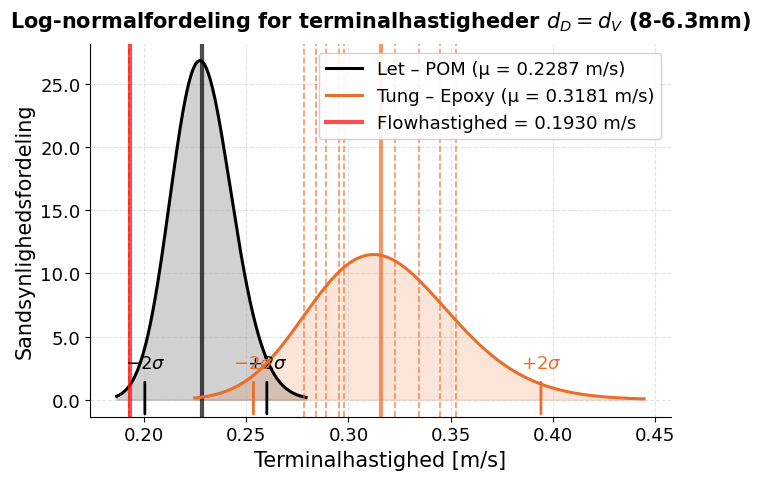

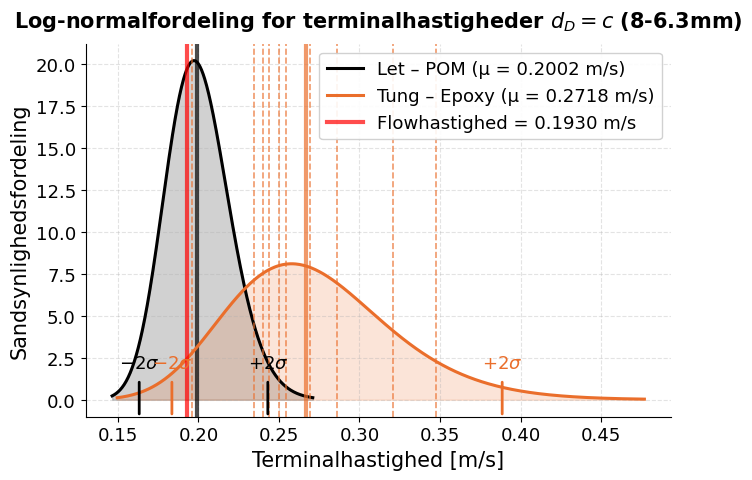

,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
Mean,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.5564,3424.9435,1.0640,0.2543,0.1724,19.2500,9.4900,5.6100,0.9067,0.4691,10.0822,9.6400
2,0.4872,1958.5498,1.0886,0.1960,0.1329,11.8300,8.5000,3.4100,0.3133,0.1621,6.9993,6.7646
3,0.6137,2359.9872,1.0794,0.2347,0.1592,11.5400,8.8200,4.8500,0.3532,0.1827,7.9032,7.0404
4,0.6848,2119.6070,1.0177,0.2440,0.1654,10.1200,7.5100,4.9400,0.0304,0.0157,7.2141,3.1085
5,0.7871,2928.1281,0.7599,0.3211,0.2178,11.9600,7.0000,6.3900,0.4577,0.2368,8.1179,7.6757
6,0.7551,2410.5818,0.8323,0.2859,0.1939,10.6800,6.7000,5.5500,0.3542,0.1832,7.3504,7.0470
7,0.7233,2349.4000,0.9081,0.2695,0.1828,11.3000,6.7700,5.3800,0.2847,0.1473,7.4385,6.5522
8,0.8245,3144.9228,0.6908,0.3474,0.2356,11.4900,7.1800,6.8000,0.3056,0.1581,8.2474,6.7087
9,0.6899,1968.7713,1.0061,0.2398,0.1626,10.0800,6.7300,4.7200,0.3171,0.1640,6.8413,6.7919
10,0.6408,2655.4173,1.0741,0.2499,0.1695,14.9600,7.6000,5.4700,0.4433,0.2293,8.5358,7.5943


In [5]:
data_light_p = [              
]

data_heavy_p = [
    [5.61, 9.49, 19.25, 0.9067],
    [3.41, 8.50, 11.83, 0.3133],
    [4.85, 8.82, 11.54, 0.3532],
    [4.94, 7.51, 10.12, 0.0304],
    [6.39, 7.00, 11.96, 0.4577],
    [5.55, 6.70, 10.68, 0.3542],
    [5.38, 6.77, 11.30, 0.2847],
    [6.80, 7.18, 11.49, 0.3056],
    [4.72, 6.73, 10.08, 0.3171],
    [5.47, 7.60, 14.96, 0.4433]
]

df_light = calculate(data_light_6_3, rho_p=rho_l, C=C, dD = "dV"); df_light_p = calculate(data_light_p, rho_p=rho_l, C=C, dD = "dV") if data_light_p else None
df_heavy = calculate(data_heavy_6_3, rho_p=rho_h, C=C, dD = "dV"); df_heavy_p = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "dV") if data_heavy_p else None

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = d_V$ (8-6.3mm)",
    points_light=df_light_p["v_single_m/s"].tolist() if df_light_p is not None else [],
    points_heavy=df_heavy_p["v_single_m/s"].tolist() if df_heavy_p is not None else [],
    v_experiment=0.193,
)

df_light = calculate(data_light_6_3, rho_p=rho_l, C=C, dD = "c"); df_light_p = calculate(data_light_p, rho_p=rho_l, C=C, dD = "c") if data_light_p else None
df_heavy = calculate(data_heavy_6_3, rho_p=rho_h, C=C, dD = "c"); df_heavy_p = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "c") if data_heavy_p else None

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = c$ (8-6.3mm)",
    points_light=df_light_p["v_single_m/s"].tolist() if df_light_p is not None else [],
    points_heavy=df_heavy_p["v_single_m/s"].tolist() if df_heavy_p is not None else [],
    v_experiment=0.193,
)

df_light = calculate(data_light_p, rho_p=rho_l, C=C, dD = "c")
df_heavy = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "c")

cols = ["psi","Re","Cd","v_single_m/s","v_hindered_m/s", "a_mm", "b_mm", "c_mm", "m_gram", "V_cm^3", "dn_mm", "dV_mm"]

for df, label in [(df_light, "LIGHT (POM)"), (df_heavy, "HEAVY (Epoxy)")]:
    d = df[cols].reset_index(drop=True)
    d.index += 1
    d.loc["Mean"] = d.mean()
    styled = (d.style.format("{:.4f}").set_caption(label)
               .set_properties(subset=pd.IndexSlice["Mean", :], **{"font-weight": "bold"}))
    display(styled)

># 4mm

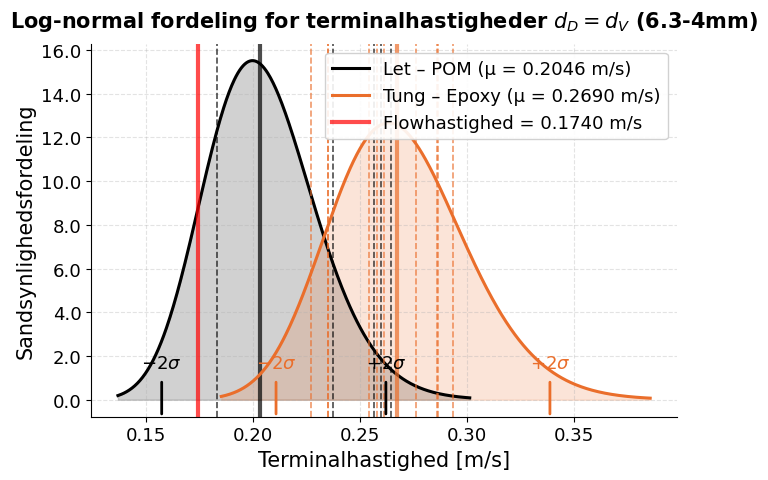

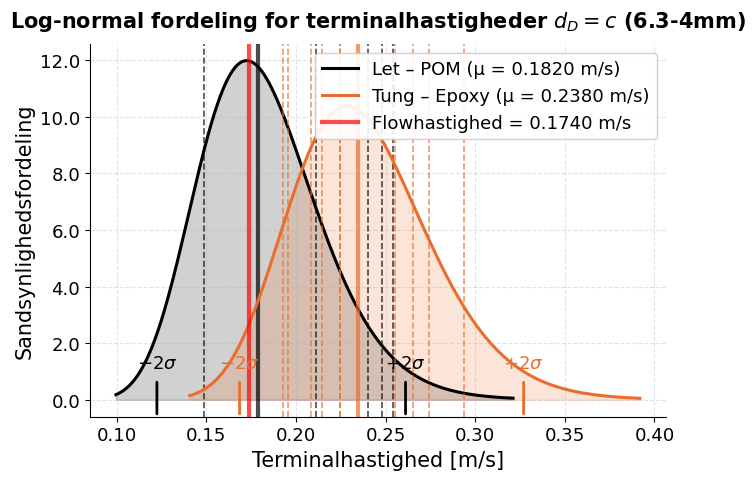

,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.5701,1281.7766,1.1143,0.1488,0.1009,11.4200,6.5400,3.7200,0.1362,0.0906,6.5252,5.5716
2,0.7851,1593.0071,0.7855,0.2110,0.1431,9.1400,6.2800,5.2700,0.2297,0.1527,6.7128,6.6319
3,0.8671,1653.0860,0.6425,0.2400,0.1628,7.8800,6.0600,5.5800,0.2170,0.1443,6.4349,6.5074
4,0.9333,1526.2385,0.5571,0.2543,0.1724,6.6300,5.4700,5.4300,0.1585,0.1054,5.8179,5.8604
5,0.9067,1566.7408,0.5894,0.2481,0.1683,7.1800,5.5900,5.4700,0.1568,0.1043,6.0326,5.8394
Mean,0.8125,1524.1698,0.7378,0.2205,0.1495,8.4500,5.9880,5.0940,0.1796,0.1194,6.3047,6.0821


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.7451,2235.2539,0.8575,0.2743,0.1860,10.7700,6.2100,5.2600,0.1881,0.0973,7.0593,5.7067
2,0.7428,2052.1266,0.8662,0.2652,0.1799,10.6100,5.6800,4.9700,0.2237,0.1157,6.6907,6.0461
3,0.6590,1262.5908,1.1154,0.1953,0.1324,8.1700,5.1500,3.4700,0.1244,0.0644,5.2657,4.9720
4,0.6650,1621.4070,1.0937,0.2147,0.1456,11.0900,5.1800,4.1100,0.0970,0.0502,6.1807,4.5763
5,0.4986,1805.5641,1.0930,0.1927,0.1307,15.4000,5.7400,3.3100,0.1174,0.0607,6.6388,4.8769
6,0.8459,1784.9787,0.6725,0.2940,0.1994,6.9900,5.3100,4.7400,0.0922,0.0477,5.6034,4.4995
7,0.5718,2296.7976,1.0807,0.2244,0.1522,14.1900,7.4300,4.4400,0.3000,0.1552,7.7646,6.6675
8,0.6052,1717.8526,1.0958,0.2086,0.1415,9.8500,6.9300,3.8900,0.1882,0.0974,6.4275,5.7077
9,0.7459,1261.3911,0.8821,0.2246,0.1523,7.1500,4.4400,3.6300,0.1080,0.0559,4.8663,4.7431
10,0.7968,1460.7393,0.7662,0.2555,0.1733,7.8900,4.1700,4.0800,0.0784,0.0406,5.1202,4.2628


In [6]:
data_light_p = [
    [3.72, 6.54, 11.42, 0.1362],
    [5.27, 6.28, 9.14, 0.2297],
    [5.58, 6.06, 7.88, 0.2170],
    [5.43, 5.47, 6.63, 0.1585],
    [5.47, 5.59, 7.18, 0.1568]
]

data_heavy_p = [
    [5.26, 6.21, 10.77, 0.1881],
    [4.97, 5.68, 10.61, 0.2237],
    [3.47, 5.15, 8.17, 0.1244],
    [4.11, 5.18, 11.09, 0.0970],
    [3.31, 5.74, 15.40, 0.1174],
    [4.74, 5.31, 6.99, 0.0922],
    [4.44, 7.43, 14.19, 0.3000],
    [3.89, 6.93, 9.85, 0.1882],
    [3.63, 4.44, 7.15, 0.1080],
    [4.08, 4.17, 7.89, 0.0784]
]

df_light = calculate(data_light_4, rho_p=rho_l, C=C, dD = "dV"); df_light_p = calculate(data_light_p, rho_p=rho_l, C=C, dD = "dV") if data_light_p else None
df_heavy = calculate(data_heavy_4, rho_p=rho_h, C=C, dD = "dV"); df_heavy_p = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "dV") if data_heavy_p else None

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normal fordeling for terminalhastigheder $d_D = d_V$ (6.3-4mm)",
    points_light=df_light_p["v_single_m/s"].tolist() if df_light_p is not None else [],
    points_heavy=df_heavy_p["v_single_m/s"].tolist() if df_heavy_p is not None else [],
    v_experiment=0.174,
)

df_light = calculate(data_light_4, rho_p=rho_l, C=C, dD = "c"); df_light_p = calculate(data_light_p, rho_p=rho_l, C=C, dD = "c") if data_light_p else None
df_heavy = calculate(data_heavy_4, rho_p=rho_h, C=C, dD = "c"); df_heavy_p = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "c") if data_heavy_p else None

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normal fordeling for terminalhastigheder $d_D = c$ (6.3-4mm)",
    points_light=df_light_p["v_single_m/s"].tolist() if df_light_p is not None else [],
    points_heavy=df_heavy_p["v_single_m/s"].tolist() if df_heavy_p is not None else [],
    v_experiment=0.174,
)

df_light = calculate(data_light_p, rho_p=rho_l, C=C, dD = "c")
df_heavy = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "c")

cols = ["psi","Re","Cd","v_single_m/s","v_hindered_m/s", "a_mm", "b_mm", "c_mm", "m_gram", "V_cm^3", "dn_mm", "dV_mm"]

for df, label in [(df_light, "LIGHT (POM)"), (df_heavy, "HEAVY (Epoxy)")]:
    d = df[cols].reset_index(drop=True)
    d.index += 1
    d.loc["Mean"] = d.mean()
    styled = (d.style.format("{:.4f}").set_caption(label)
               .set_properties(subset=pd.IndexSlice["Mean", :], **{"font-weight": "bold"}))
    display(styled)

># 1,8mm


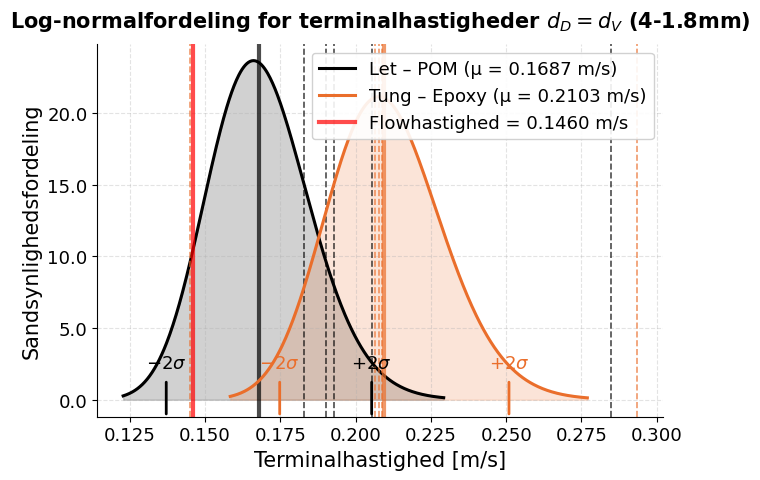

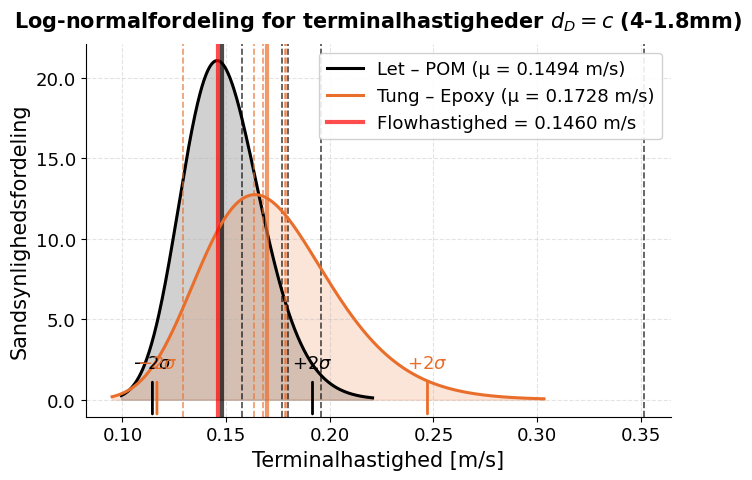

,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.8300,849.4032,0.7329,0.1800,0.1245,5.6600,3.9600,3.5800,0.0535,0.0356,4.3132,4.0804
2,0.7508,814.2484,0.8987,0.1577,0.1090,6.8100,3.9400,3.3700,0.0707,0.0470,4.4884,4.4777
3,0.8138,861.9263,0.7615,0.1769,0.1224,6.2600,3.8200,3.5900,0.0556,0.0370,4.4114,4.1331
4,1.1770,1779.0774,0.3474,0.3518,0.2386,6.3900,4.0300,6.4800,0.0625,0.0416,5.5055,4.2975
5,0.8600,953.0994,0.6766,0.1956,0.1359,5.9200,4.0400,3.9000,0.0620,0.0412,4.5351,4.2860
Mean,0.8863,1051.5509,0.6834,0.2124,0.1461,6.2080,3.9580,4.1840,0.0609,0.0405,4.6507,4.2549


,psi,Re,Cd,v_single_m/s,v_hindered_m/s,a_mm,b_mm,c_mm,m_gram,V_cm^3,dn_mm,dV_mm
1,0.6455,847.0846,1.1477,0.1676,0.1160,8.0100,3.2100,2.6300,0.0615,0.0318,4.0741,3.9314
2,0.6202,440.5049,1.2251,0.1293,0.0872,5.0600,2.3100,1.6700,0.0090,0.0047,2.6925,2.0717
3,0.5776,925.3319,1.1398,0.1637,0.1136,7.1200,4.5200,2.4900,0.0620,0.0321,4.3113,3.9420
4,0.6155,1079.6518,1.1270,0.1785,0.1211,7.6700,4.8000,2.9300,0.0631,0.0326,4.7603,3.9652
5,0.6860,879.8211,1.0699,0.1791,0.1241,6.9000,3.5200,2.8000,0.3890,0.2012,4.0818,7.2706
Mean,0.6290,834.4789,1.1419,0.1637,0.1124,6.9520,3.6720,2.5040,0.1169,0.0605,3.9840,4.2362


In [7]:
data_light_p = [
    [3.58, 3.96, 5.66, 0.0535],
    [3.37, 3.94, 6.81, 0.0707],
    [3.59, 3.82, 6.26, 0.0556],
    [6.48, 4.03, 6.39, 0.0625],
    [3.90, 4.04, 5.92, 0.0620]
]

data_heavy_p = [ 
    [2.63, 3.21, 8.01, 0.0615],
    [1.67, 2.31, 5.06, 0.0090],
    [2.49, 4.52, 7.12, 0.0620],
    [2.93, 4.80, 7.67, 0.0631],
    [2.80, 3.52, 6.90, 0.3890]               
]

df_light = calculate(data_light_1_8, rho_p=rho_l, C=C, dD = "dV"); df_light_p = calculate(data_light_p, rho_p=rho_l, C=C, dD = "dV") if data_light_p else None
df_heavy = calculate(data_heavy_1_8, rho_p=rho_h, C=C, dD = "dV"); df_heavy_p = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "dV") if data_heavy_p else None

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = d_V$ (4-1.8mm)",
    points_light=df_light_p["v_single_m/s"].tolist() if df_light_p is not None else [],
    points_heavy=df_heavy_p["v_single_m/s"].tolist() if df_heavy_p is not None else [],
    v_experiment=0.146,
)

df_light = calculate(data_light_1_8, rho_p=rho_l, C=C, dD = "c"); df_light_p = calculate(data_light_p, rho_p=rho_l, C=C, dD = "c") if data_light_p else None
df_heavy = calculate(data_heavy_1_8, rho_p=rho_h, C=C, dD = "c"); df_heavy_p = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "c") if data_heavy_p else None

plot_normal_pair(
    df_light["v_single_m/s"].values,
    df_heavy["v_single_m/s"].values,
    xlabel="Terminalhastighed [m/s]",
    title="Log-normalfordeling for terminalhastigheder $d_D = c$ (4-1.8mm)",
    points_light=df_light_p["v_single_m/s"].tolist() if df_light_p is not None else [],
    points_heavy=df_heavy_p["v_single_m/s"].tolist() if df_heavy_p is not None else [],
    v_experiment=0.146,
)

df_light = calculate(data_light_p, rho_p=rho_l, C=C, dD = "c")
df_heavy = calculate(data_heavy_p, rho_p=rho_h, C=C, dD = "c")

cols = ["psi","Re","Cd","v_single_m/s","v_hindered_m/s", "a_mm", "b_mm", "c_mm", "m_gram", "V_cm^3", "dn_mm", "dV_mm"]

for df, label in [(df_light, "LIGHT (POM)"), (df_heavy, "HEAVY (Epoxy)")]:
    d = df[cols].reset_index(drop=True)
    d.index += 1
    d.loc["Mean"] = d.mean()
    styled = (d.style.format("{:.4f}").set_caption(label)
               .set_properties(subset=pd.IndexSlice["Mean", :], **{"font-weight": "bold"}))
    display(styled)

# Renhed og udbytte (andel-baseret)

In [8]:
# === Renhed og udbytte (ANDEL-baseret) ===
# Beregnet ud fra den fittede log-normalfordeling af v_single (samme data som
# fordelingsplottene). En partikel synker til underflow hvis v_single > v_flow,
# ellers loftes den til overflow. Renhed og udbytte er ANDELE (areal under
# fordelingen), ikke masse. Renheden forudsaetter samme udgangsandel af hvert
# materiale; den reelle masse-renhed afhaenger af blandingsforholdet.
import numpy as np
from scipy.stats import lognorm

def _fit_ln(vals):
    vals = np.asarray(vals, dtype=float)
    shape, loc, scale = lognorm.fit(vals, floc=0)
    return shape, scale

def renhed_udbytte(v_light, v_heavy, v_flow):
    """light loftes (overflow) hvis v < v_flow ; heavy synker (underflow) hvis v > v_flow."""
    sL, scL = _fit_ln(v_light)
    sH, scH = _fit_ln(v_heavy)
    light_over = lognorm.cdf(v_flow, sL, 0, scL)   # let i overflow (korrekt)
    heavy_over = lognorm.cdf(v_flow, sH, 0, scH)    # tung i overflow (forkert)
    light_under = 1 - light_over                    # let i underflow (forkert)
    heavy_under = 1 - heavy_over                     # tung i underflow (korrekt)
    return {
        "Overflow renhed %":   100*light_over /(light_over + heavy_over),
        "Overflow udbytte %":  100*light_over,
        "Underflow renhed %":  100*heavy_under/(heavy_under + light_under),
        "Underflow udbytte %": 100*heavy_under,
    }

def vis(label, v_light, v_heavy, v_flow):
    r = renhed_udbytte(v_light, v_heavy, v_flow)
    print(f"{label}  (v_flow = {v_flow} m/s)")
    print(f"   Overflow  (let):   renhed {r['Overflow renhed %']:6.1f} %   udbytte {r['Overflow udbytte %']:6.1f} %")
    print(f"   Underflow (tung):  renhed {r['Underflow renhed %']:6.1f} %   udbytte {r['Underflow udbytte %']:6.1f} %")
    print()
    return r

# --- Epoxy-POM: tre fraktioner, begge diametre ---
fraktioner = [
    ("8-6,3 mm", data_light_6_3, data_heavy_6_3, 0.193),
    ("6,3-4 mm", data_light_4,   data_heavy_4,   0.174),
    ("4-1,8 mm", data_light_1_8, data_heavy_1_8, 0.146),
]
for navn, L, H, vf in fraktioner:
    for dD in ["c", "dV"]:
        vL = calculate(L, rho_p=rho_l, C=C, dD=dD)["v_single_m/s"].values
        vH = calculate(H, rho_p=rho_h, C=C, dD=dD)["v_single_m/s"].values
        vis(f"Epoxy-POM | {navn} | d_D = {dD}", vL, vH, vf)


Epoxy-POM | 8-6,3 mm | d_D = c  (v_flow = 0.193 m/s)
   Overflow  (let):   renhed   90.6 %   udbytte   37.3 %
   Underflow (tung):  renhed   60.5 %   udbytte   96.1 %

Epoxy-POM | 8-6,3 mm | d_D = dV  (v_flow = 0.193 m/s)
   Overflow  (let):   renhed   99.9 %   udbytte    0.4 %
   Underflow (tung):  renhed   50.1 %   udbytte  100.0 %

Epoxy-POM | 6,3-4 mm | d_D = c  (v_flow = 0.174 m/s)
   Overflow  (let):   renhed   93.1 %   udbytte   44.2 %
   Underflow (tung):  renhed   63.4 %   udbytte   96.7 %

Epoxy-POM | 6,3-4 mm | d_D = dV  (v_flow = 0.174 m/s)
   Overflow  (let):   renhed   99.9 %   udbytte   10.9 %
   Underflow (tung):  renhed   52.9 %   udbytte  100.0 %

Epoxy-POM | 4-1,8 mm | d_D = c  (v_flow = 0.146 m/s)
   Overflow  (let):   renhed   68.8 %   udbytte   45.5 %
   Underflow (tung):  renhed   59.3 %   udbytte   79.4 %

Epoxy-POM | 4-1,8 mm | d_D = dV  (v_flow = 0.146 m/s)
   Overflow  (let):   renhed  100.0 %   udbytte    8.0 %
   Underflow (tung):  renhed   52.1 %   udbytte

# Teoretisk optimal separation

In [9]:
# === Teoretisk optimal separation (andel-baseret) ===
# For hver fraktion findes den flowhastighed der MAKSIMERER det samlede udbytte
# (POM op + Epoxy ned). Dette er den teoretiske oevre graense for separationen
# givet fordelingernes overlap. Renhed og udbytte er andele, ikke masse.
import numpy as np
from scipy.stats import lognorm

def _fit_ln(vals):
    vals = np.asarray(vals, dtype=float)
    shape, loc, scale = lognorm.fit(vals, floc=0)
    return shape, scale

def optimal_separation(v_light, v_heavy, n=4000):
    """Finder flowhastigheden der maksimerer samlet udbytte (let op + tung ned)."""
    sL, scL = _fit_ln(v_light)
    sH, scH = _fit_ln(v_heavy)
    lo = min(v_light.min(), v_heavy.min())
    hi = max(v_light.max(), v_heavy.max())
    flows = np.linspace(lo, hi, n)
    best = None
    for f in flows:
        pom_over  = lognorm.cdf(f, sL, 0, scL)      # let i overflow (udbytte)
        epx_under = 1 - lognorm.cdf(f, sH, 0, scH)  # tung i underflow (udbytte)
        tot = pom_over + epx_under
        if best is None or tot > best[0]:
            epx_over  = lognorm.cdf(f, sH, 0, scH)
            pom_under = 1 - pom_over
            ren_over  = pom_over  / (pom_over + epx_over)
            ren_under = epx_under / (epx_under + pom_under)
            best = (tot, f, pom_over, epx_under, ren_over, ren_under)
    _, f, po, eu, ro, ru = best
    return {"v_optimal": f, "Overflow renhed %": 100*ro, "Overflow udbytte %": 100*po,
            "Underflow renhed %": 100*ru, "Underflow udbytte %": 100*eu}

def vis_optimal(navn, v_light, v_heavy):
    r = optimal_separation(v_light, v_heavy)
    print(f"{navn}: optimal flowhastighed = {r['v_optimal']:.3f} m/s")
    print(f"   Overflow  (POM):   renhed {r['Overflow renhed %']:5.1f} %   udbytte {r['Overflow udbytte %']:5.1f} %")
    print(f"   Underflow (Epoxy): renhed {r['Underflow renhed %']:5.1f} %   udbytte {r['Underflow udbytte %']:5.1f} %")
    print()
    return r

# Bemaerk: 'optimal' her maksimerer samlet udbytte. Selv ved denne hastighed kan
# modellen ikke give rene fraktioner i begge ender, fordi fordelingerne overlapper.
fraktioner_opt = [
    ("8-6,3 mm", data_light_6_3, data_heavy_6_3),
    ("6,3-4 mm", data_light_4,   data_heavy_4),
    ("4-1,8 mm", data_light_1_8, data_heavy_1_8),
]
for navn, L, H in fraktioner_opt:
    vL = calculate(L, rho_p=rho_l, C=C, dD="c")["v_single_m/s"].values
    vH = calculate(H, rho_p=rho_h, C=C, dD="c")["v_single_m/s"].values
    vis_optimal(f"Epoxy-POM | {navn} | d_D = c", vL, vH)


Epoxy-POM | 8-6,3 mm | d_D = c: optimal flowhastighed = 0.229 m/s
   Overflow  (POM):   renhed  82.3 %   udbytte  92.1 %
   Underflow (Epoxy): renhed  91.0 %   udbytte  80.1 %

Epoxy-POM | 6,3-4 mm | d_D = c: optimal flowhastighed = 0.204 m/s
   Overflow  (POM):   renhed  79.9 %   udbytte  75.9 %
   Underflow (Epoxy): renhed  77.0 %   udbytte  80.9 %

Epoxy-POM | 4-1,8 mm | d_D = c: optimal flowhastighed = 0.165 m/s
   Overflow  (POM):   renhed  64.6 %   udbytte  81.0 %
   Underflow (Epoxy): renhed  74.5 %   udbytte  55.5 %

